**ROLL NO : 24BAD087**  
**NAME : POOVIKA M**

**EXP NO : 6**

**IMPLEMENTATION OF LSTM FOR SENTIMENT ANALYSIS**

Part A: Data Loading and Preprocessing

In [2]:
!pip install -q datasets

import numpy as np
import pandas as pd
import re

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Load dataset
dataset = load_dataset("fancyzhx/amazon_polarity")

# Select balanced subsets
TRAIN_SIZE = 20000
TEST_SIZE = 4000

train_pos = dataset["train"].filter(
    lambda x: x["label"] == 1
).shuffle(seed=42).select(range(TRAIN_SIZE // 2))

train_neg = dataset["train"].filter(
    lambda x: x["label"] == 0
).shuffle(seed=42).select(range(TRAIN_SIZE // 2))

test_pos = dataset["test"].filter(
    lambda x: x["label"] == 1
).shuffle(seed=42).select(range(TEST_SIZE // 2))

test_neg = dataset["test"].filter(
    lambda x: x["label"] == 0
).shuffle(seed=42).select(range(TEST_SIZE // 2))

train_df = pd.concat([
    train_pos.to_pandas(),
    train_neg.to_pandas()
]).sample(frac=1, random_state=42).reset_index(drop=True)

test_df = pd.concat([
    test_pos.to_pandas(),
    test_neg.to_pandas()
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))
print("\nTraining class distribution:")
print(train_df["label"].value_counts())

# Combine title and review
train_df["text"] = (
    train_df["title"].fillna("") + " " +
    train_df["content"].fillna("")
)

test_df["text"] = (
    test_df["title"].fillna("") + " " +
    test_df["content"].fillna("")
)

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

X_train_text = train_df["clean_text"].values
y_train = train_df["label"].values

X_test_text = test_df["clean_text"].values
y_test = test_df["label"].values

# Tokenization
VOCAB_SIZE = 10000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

X_train_sequences = tokenizer.texts_to_sequences(X_train_text)
X_test_sequences = tokenizer.texts_to_sequences(X_test_text)

# Padding
MAX_LENGTH = 200

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

# Train-validation split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_padded,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("\nTraining shape:", X_train_final.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test_padded.shape)

README.md:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

amazon_polarity/train-00000-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  260MB            

amazon_polarity/train-00000-of-00004.par(…): downloading bytes:           |  0.00B            

amazon_polarity/train-00001-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  258MB            

amazon_polarity/train-00001-of-00004.par(…): downloading bytes:           |  0.00B            

...

Filter:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/400000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/400000 [00:00<?, ? examples/s]

Training samples: 20000
Testing samples: 4000

Training class distribution:
label
0    10000
1    10000
Name: count, dtype: int64

Training shape: (16000, 200)
Validation shape: (4000, 200)
Testing shape: (4000, 200)


Part B: Word Embedding

In [3]:
import tensorflow as tf

# Embedding layer
EMBEDDING_DIM = 128

embedding_layer = tf.keras.layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)

sample_input = tf.convert_to_tensor(X_train_padded[:1])

sample_embedding = embedding_layer(sample_input)

print("Input shape:", sample_input.shape)
print("Embedding shape:", sample_embedding.shape)

Input shape: (1, 200)
Embedding shape: (1, 200, 128)


Part C: LSTM Model

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Build model
model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Part D: Training, Evaluation and Prediction

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 67s 261ms/step - accuracy: 0.7611 - loss: 0.5076 - val_accuracy: 0.7990 - val_loss: 0.4562
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 70s 281ms/step - accuracy: 0.8435 - loss: 0.3871 - val_accuracy: 0.8125 - val_loss: 0.4794
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 69s 276ms/step - accuracy: 0.8425 - loss: 0.3764 - val_accuracy: 0.8152 - val_loss: 0.4026
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 69s 278ms/step - accuracy: 0.8421 - loss: 0.3702 - val_accuracy: 0.8155 - val_loss: 0.4103
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 67s 268ms/step - accuracy: 0.9121 - loss: 0.2356 - val_accuracy: 0.8640 - val_loss: 0.3590
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 66s 266ms/step - accuracy: 0.9471 - loss: 0.1527 - val_accuracy: 0.8648 - val_loss: 0.3704
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 72s 287ms/step - accuracy: 0.9672 - loss: 0.1024 - val_accuracy: 0.8648 - val_loss: 0.3799
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 68s 271ms/step - accuracy: 0.9792 - loss: 0

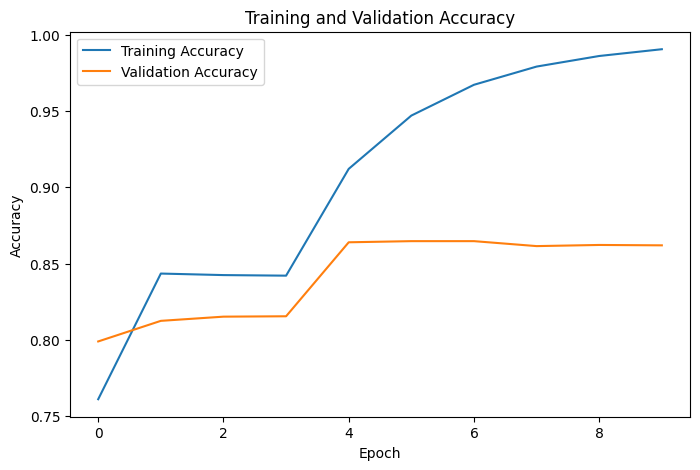

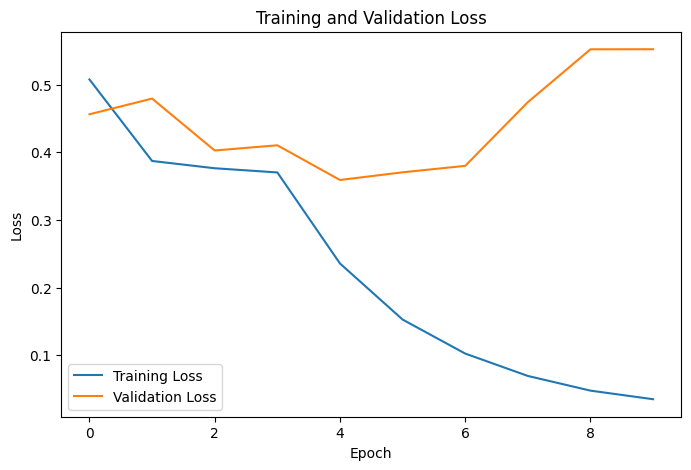

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8620 - loss: 0.5330

Test Loss: 0.5329965949058533
Test Accuracy: 0.8619999885559082

Accuracy : 0.862
Precision: 0.8834745762711864
Recall   : 0.834
F1 Score : 0.8580246913580247

Confusion Matrix:
[[1780  220]
 [ 332 1668]]


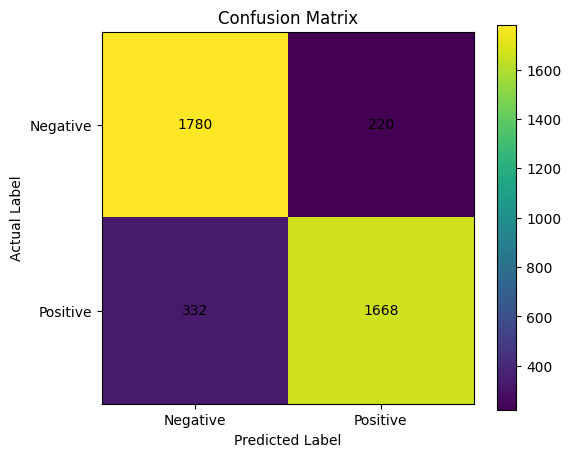


Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.89      0.87      2000
    Positive       0.88      0.83      0.86      2000

    accuracy                           0.86      4000
   macro avg       0.86      0.86      0.86      4000
weighted avg       0.86      0.86      0.86      4000


Sample Predictions:

Review: This product is excellent and I really loved it.
Sentiment: Positive
Probability: 0.992

Review: Very poor quality and completely disappointed.
Sentiment: Negative
Probability: 0.0008

Review: The product works well and is worth the money.
Sentiment: Positive
Probability: 0.8733

Review: Terrible product. I would never buy it again.
Sentiment: Negative
Probability: 0.0017


In [7]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Train model
EPOCHS = 10
BATCH_SIZE = 64

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Evaluate model
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Predictions
y_probability = model.predict(
    X_test_padded,
    verbose=0
).flatten()

y_pred = (y_probability >= 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])
plt.show()

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

# Sample predictions
def predict_sentiment(review):
    cleaned_review = clean_text(review)

    sequence = tokenizer.texts_to_sequences([cleaned_review])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    probability = float(
        model.predict(padded_sequence, verbose=0)[0][0]
    )

    sentiment = "Positive" if probability >= 0.5 else "Negative"

    return sentiment, probability


sample_reviews = [
    "This product is excellent and I really loved it.",
    "Very poor quality and completely disappointed.",
    "The product works well and is worth the money.",
    "Terrible product. I would never buy it again."
]

print("\nSample Predictions:")

for review in sample_reviews:
    sentiment, probability = predict_sentiment(review)

    print("\nReview:", review)
    print("Sentiment:", sentiment)
    print("Probability:", round(probability, 4))